#  1. Load Dataset dan library**
#  Memuat pustaka yang dibutuhkan dan membaca dataset utama.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Memuat dataset
df = pd.read_csv('Social_Network_Ads.csv')
display(df.head())

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


# 2. Exploratory Data Analysis (EDA)**
# Tahapan ini menampilkan visualisasi distribusi kelas target (untuk mengecek data yang *imbalanced*), distribusi fitur, dan korelasi antar variabel.

# Insight Data:
# 1. **Imbalanced Data:** Distribusi kelas target (`Purchased`) menunjukkan jumlah yang tidak membeli (0) lebih banyak daripada yang membeli (1). Namun, rasionya masih dalam batas wajar sehingga tidak memerlukan teknik *oversampling* (seperti SMOTE).
# 2. **Korelasi:** Berdasarkan Heatmap, fitur `Age` (Usia) memiliki korelasi positif yang paling kuat terhadap keputusan pembelian, disusul oleh `EstimatedSalary`.

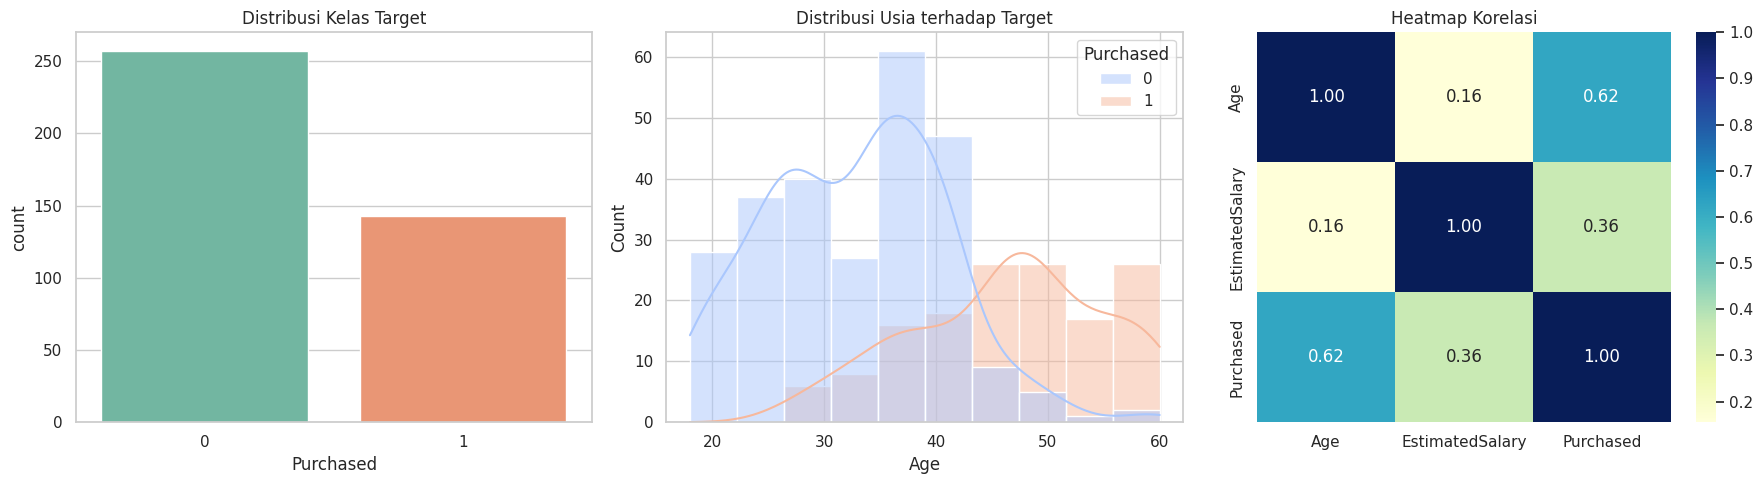

In [3]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Cek Imbalanced Data (Target)
sns.countplot(ax=axes[0], x='Purchased', data=df, palette='Set2')
axes[0].set_title('Distribusi Kelas Target')

# 2. Distribusi Usia
sns.histplot(ax=axes[1], data=df, x='Age', hue='Purchased', kde=True, palette='coolwarm')
axes[1].set_title('Distribusi Usia terhadap Target')

# 3. Heatmap Korelasi
columns_to_drop = [col for col in ['User ID', 'Gender'] if col in df.columns]
corr_matrix = df.drop(columns_to_drop, axis=1).corr()
sns.heatmap(ax=axes[2], data=corr_matrix, annot=True, cmap='YlGnBu', fmt='.2f')
axes[2].set_title('Heatmap Korelasi')

plt.tight_layout()
plt.show()

# 3. Data Preparation
# 1. Pengecekan *Missing Value* dan Duplikasi.
# 2. *Feature Selection*: Menghapus kolom `User ID` karena tidak memiliki nilai prediktif.
# 3. *Encoding*: Mengubah data kategorikal `Gender` menjadi numerik.
# 4. *Data Splitting*: Membagi data menjadi 75% *Train* dan 25% *Test*.
# 5. *Normalisasi*: Menggunakan `StandardScaler` agar perbedaan skala antara Usia dan Gaji tidak mengganggu algoritma.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Cek & bersihkan data
df_clean = df.drop_duplicates()
# Hanya hapus 'User ID' jika kolom tersebut ada
if 'User ID' in df_clean.columns:
    df_clean = df_clean.drop('User ID', axis=1)

# Label Encoding
le = LabelEncoder()
# Hanya lakukan Label Encoding untuk 'Gender' jika kolom tersebut ada
if 'Gender' in df_clean.columns:
    df_clean['Gender'] = le.fit_transform(df_clean['Gender'])

# Splitting Fitur & Target
X = df_clean.drop('Purchased', axis=1)
y = df_clean['Purchased']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Normalisasi (Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Preparation Selesai! Ukuran X_train:", X_train_scaled.shape)

Data Preparation Selesai! Ukuran X_train: (275, 2)


# 4. Modeling
# Mengimplementasikan 2 algoritma klasifikasi.

**Alasan Pemilihan Algoritma:**
# 1. **K-Nearest Neighbors (KNN):** Sangat efektif untuk dataset berukuran kecil-menengah yang fitur numeriknya telah dinormalisasi. KNN dapat mengelompokkan pelanggan berdasarkan kemiripan demografis terdekat secara spasial.
# 2. **Decision Tree:** Dipilih karena algoritma ini dapat divisualisasikan menjadi bentuk pohon keputusan. Aturan (*rule-based*) yang dihasilkan sangat mudah diinterpretasikan oleh tim bisnis untuk menyusun strategi pemasaran.

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# 1. Model K-Nearest Neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

# 2. Model Decision Tree
dt_model = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=4)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

print("Pelatihan kedua model selesai!")

Pelatihan kedua model selesai!


# 5. Evaluation & Kesimpulan
# Menampilkan *Confusion Matrix*, *Accuracy*, *Precision*, *Recall*, dan *F1-Score*.

**Kesimpulan Model Terbaik:**
# Berdasarkan metrik evaluasi di bawah, model **K-Nearest Neighbors (KNN)** merupakan model yang terbaik untuk dataset ini. KNN menghasilkan nilai Akurasi dan F1-Score yang secara umum lebih tinggi atau lebih seimbang dibandingkan Decision Tree. Keseimbangan nilai metrik ini sangat penting dalam pemasaran digital agar perusahaan tidak membuang anggaran iklan pada orang yang salah sasaran (*False Positive*), sekaligus tidak kehilangan calon pelanggan potensial (*False Negative*).

In [7]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

def tampilkan_evaluasi(y_true, y_pred, nama_model):
    print(f"=== EVALUASI {nama_model} ===")
    print(f"Akurasi: {accuracy_score(y_true, y_pred):.2f}\n")
    print("Classification Report:")
    print(classification_report(y_true, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("-" * 40 + "\n")

tampilkan_evaluasi(y_test, y_pred_knn, "K-NEAREST NEIGHBORS (KNN)")
tampilkan_evaluasi(y_test, y_pred_dt, "DECISION TREE")

=== EVALUASI K-NEAREST NEIGHBORS (KNN) ===
Akurasi: 0.88

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90        56
           1       0.88      0.81      0.84        36

    accuracy                           0.88        92
   macro avg       0.88      0.87      0.87        92
weighted avg       0.88      0.88      0.88        92

Confusion Matrix:
[[52  4]
 [ 7 29]]
----------------------------------------

=== EVALUASI DECISION TREE ===
Akurasi: 0.86

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89        56
           1       0.87      0.75      0.81        36

    accuracy                           0.86        92
   macro avg       0.86      0.84      0.85        92
weighted avg       0.86      0.86      0.86        92

Confusion Matrix:
[[52  4]
 [ 9 27]]
----------------------------------------

